## Coupled simulation — overview and imports


In [1]:
"""
coupled_simulation.py
=====================

Coupled dFBA (porcine cell, proteome-constrained) + kinetic ODE (synthetic
E. coli) simulation with a single shared extracellular pool.

Numerical scheme
----------------
Jacobi (simultaneous) operator splitting:
  Both models read S(t) - the pool is frozen during each substep.
  ΔS contributions are summed once and applied atomically.
  S(t+Δt) = max( S(t) + ΔS_dfba + ΔS_kinetic , 0 )

Units
-----
  Concentrations : mM
  Time           : hr
  Protein        : mg/L
  Cell density   : gDW/L
  dFBA fluxes    : mmol gDW⁻¹ hr⁻¹  →  scaled by n1_gDW to give mM/hr
  ODE fluxes     : mM/hr

Dependencies: cobra, scipy, numpy, pandas, fba_functions.py on PYTHONPATH.
"""

import time
import warnings
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import root
import cobra
from pathlib import Path
import sys

OUTPUT_DIR = Path("output") / "Combined_sim"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figure output directory: {OUTPUT_DIR.resolve()}")

# Resolve fba_functions.py from common local locations.
PROJECT_DIR = Path.cwd()
search_roots = [
    PROJECT_DIR,
    PROJECT_DIR / "src",
    PROJECT_DIR / "code",
    PROJECT_DIR.parent,
]
for search_root in search_roots:
    if (search_root / "fba_functions.py").exists() and str(search_root) not in sys.path:
        sys.path.insert(0, str(search_root))

try:
    from fba_functions import (
        pcfba,
        inhibit_gln,
        nh4_inhibit_glc,
        inhibit_our,
        ex_aa_list,
        set_PA,
    )
except ModuleNotFoundError as exc:
    searched = "\n".join(str(p / "fba_functions.py") for p in search_roots)
    raise ModuleNotFoundError(
        "Could not import fba_functions. Please add fba_functions.py to one of:\n"
        f"{searched}"
    ) from exc

# ═════════════════════════════════════════════════════════════════════════════
# BLOCK 1 — SHARED POOL


Figure output directory: C:\Users\bcsma\OneDrive - Imperial College London\Documents\Ben\Post-doc\SimCells-for-Cultured-Meat\output\Combined_sim


## Extracellular metabolites (`MEDIUM_CONC_DMEM_F12`, `NAME_MAP`, …)


In [2]:
# ═════════════════════════════════════════════════════════════════════════════

# Initial medium concentrations for tracked amino acids (mM), DMEM/F12 + E8.
MEDIUM_CONC_DMEM_F12 = {
    "lac" : 0.5,     # mM — small seed for SimCell start-up
    "nh4" : 0.31,    # mM
    "arg" : 0.5,     # mM
    "glc" : 11.567,  # mM — primary carbon source
    "gln" : 3.333,   # mM — primary nitrogen source
}

# Canonical key → (GEM reaction ID, ODE pool key). ODE key is None
# for metabolites not consumed by the E. coli kinetic ODE.
NAME_MAP = {
    "lac" : ("EX_lac__L_e", "lac_e"),
    "nh4" : ("EX_nh4_e",    "nh4_e"),
    "arg" : ("EX_arg__L_e", "arg_e"),
    "glc" : ("EX_glc__D_e", None),
    "gln" : ("EX_gln__L_e", None),
}

ODE_POOL_KEYS  = ["lac", "nh4", "arg"]
DFBA_POOL_KEYS = ["lac", "nh4", "arg", "glc", "gln"]


class SharedPool:
    """Single shared extracellular metabolite pool with optional perfusion."""

    def __init__(self, init: dict, k_eff=1.0, feed: dict | None = None, D_med: float = 0.0):
        self.S = {k: float(v) for k, v in init.items()}

        if feed is None:
            self.feed = {k: float(v) for k, v in init.items()}
        else:
            self.feed = {k: float(v) for k, v in feed.items()}

        self.D_med = float(D_med)   # medium turnover (1/hr)

        # Normalise k_eff to a per-metabolite dict
        if isinstance(k_eff, (int, float)):
            self._k_eff = {k: float(k_eff) for k in NAME_MAP}
        else:
            self._k_eff = {k: float(k_eff.get(k, 1.0)) for k in NAME_MAP}

    def k_eff(self, met: str) -> float:
        return self._k_eff.get(met, 1.0)

    def clamp(self):
        """Hard non-negativity clamp."""
        for k in self.S:
            if self.S[k] < 0.0:
                self.S[k] = 0.0

    def snapshot(self) -> dict:
        return dict(self.S)

    def apply_delta(self, delta: dict):
        """Apply ΔS dict with a per-term depletion guard."""
        for k, dv in delta.items():
            if k not in self.S:
                continue
            capped = max(dv, -self.S[k])
            self.S[k] += capped

    def gem_id(self, met: str) -> str:
        return NAME_MAP[met][0]

    def ode_key(self, met: str):
        return NAME_MAP[met][1]

# ═════════════════════════════════════════════════════════════════════════════
# BLOCK 2 — dFBA STEP  (porcine mammalian cell)

# ═════════════════════════════════════════════════════════════════════════════


## `SharedPool` — extracellular pool + perfusion


## `step_dfba` — porcine proteome-constrained PFBA step


In [3]:
def step_dfba(
    pool: SharedPool,
    n1_gDW: float,
    dt: float,
    model: cobra.Model,
    ptot: float,
    O_frac: float,
    NGAM: float,
    A_dict: dict,
    v_min: float = 0.01,
    OUR_vmin: float = 0.6,
) -> tuple[dict, float, str]:
    """
    Run one dFBA substep using S(t). Pool is NOT modified here; ΔS_dfba is
    returned and applied in resolve_update() with ΔS_kinetic.
    """
    lac = pool.S.get("lac", 0.0)
    nh4 = pool.S.get("nh4", 0.0)

    # Kinetic inhibition bounds (mmol/gDW/hr)
    AA_lb  = inhibit_gln(lac, nh4, v_min)
    Glc_lb = nh4_inhibit_glc(lac, nh4, v_min)
    OUR_lb = inhibit_our(lac, nh4, OUR_vmin)

    # Depletion guard: v_max = S[met] / (n1 * dt)
    guard = 1.0 / max(n1_gDW * dt, 1e-12)
    Glc_lb = min(Glc_lb, pool.S.get("glc", 0.0) * guard)

    # LP solve with per-reaction bounds
    lp_status = "optimal"
    try:
        with model:
            for gem_id in ex_aa_list:
                model.reactions.get_by_id(gem_id).lower_bound = -AA_lb
            model.reactions.EX_glc__D_e.lower_bound = -Glc_lb
            model.reactions.EX_o2_e.lower_bound      = -OUR_lb
            model.reactions.ATPM.lower_bound          = NGAM

            set_PA(model, ptot, A_dict, O_frac)

            fluxes = cobra.flux_analysis.pfba(model).fluxes
        mu = float(fluxes.get("BIOMASS", 0.0))

    except Exception:
        lp_status = "infeasible"
        mu = 0.0
        fluxes = {NAME_MAP[k][0]: 0.0 for k in DFBA_POOL_KEYS
                  if NAME_MAP[k][0] is not None}
        fluxes["BIOMASS"] = 0.0

    # ΔS contribution (mM): v × n1 × dt × k_eff. Positive = secretion.
    dS_dfba = {}
    for met in DFBA_POOL_KEYS:
        gem_id = NAME_MAP[met][0]
        if gem_id is None:
            continue
        v = float(fluxes.get(gem_id, 0.0))
        dS_dfba[met] = v * n1_gDW * dt * pool.k_eff(met)

    # Instantaneous pool rate contribution (mM/hr)
    rates_dfba = {}
    for met in DFBA_POOL_KEYS:
        gem_id = NAME_MAP[met][0]
        if gem_id is None:
            continue
        v = float(fluxes.get(gem_id, 0.0))
        rates_dfba[met] = v * n1_gDW * pool.k_eff(met)

    return dS_dfba, mu, lp_status, rates_dfba

# ═════════════════════════════════════════════════════════════════════════════
# BLOCK 3 — KINETIC ODE STEP  (synthetic E. coli)


## SimCell layout (`Y1_IDX`, `DECAY_RATES`, `K_PARAMS`)


In [4]:
# ═════════════════════════════════════════════════════════════════════════════
# State vector (17 elements):
#    0  lac_c     intracellular L-lactate (mM_cyto)
#    1  nh4_c     intracellular ammonium (mM_cyto)
#    2  accoa     acetyl-CoA (mM_cyto)
#    3  arg_c     intracellular L-arginine (mM_cyto)
#    4  atp       ATP (mM)   } conserved: atp + adp = A_tot
#    5  adp       ADP (mM)   }
#    6  polyp     polyphosphate (mM)
#    7  lac_e     extracellular lactate (mM_bio)     (Jacobi-frozen)
#    8  nh4_e     extracellular ammonium (mM_bio)    (Jacobi-frozen)
#    9  arg_e     extracellular arginine (mM_bio)    (Jacobi-frozen)
#   10  P_lacT    lldP + glycolate permease (mg/L_cyto)
#   11  P_P1      lldD + PDH (mg/L_cyto)
#   12  P_tca     TCA enzymes (mg/L_cyto)
#   13  P_P2      ArgA–ArgH enzymes (mg/L_cyto)
#   14  P_argT    ArgO exporter (mg/L_cyto)
#   15  P_ppk     PPK (mg/L_cyto)
#   16  n_atp_eff effective ETC ATP yield

# ── Volume scaling ─────────────────────────────────────────────────────────
CELL_DENSITY_DCW = 45         # gDW_SimCell / L_bioreactor
V_PER_DCW        = 2.0e-3     # L_cytoplasm / gDW
PHI_CELL         = CELL_DENSITY_DCW * V_PER_DCW   # L_cyto / L_bio
V_RATIO          = 1.0 / PHI_CELL                  # L_bio / L_cyto

PTOT_TO_GDW = 550.0   # mg protein / gDW

# ── Decay rates ────────────────────────────────────────────────────────────
DECAY_RATES = dict(
    D_cyto = 0.003,
    D_mem  = 0.003,
    D_etc  = 0.003,
)

PROTEIN_DECAY_MAP = dict(
    P_lacT = "D_mem",
    P_P1   = "D_cyto",
    P_tca  = "D_cyto",
    P_P2   = "D_cyto",
    P_argT = "D_mem",
    P_ppk  = "D_cyto",
)

N_PROTEIN_CLASSES = len(PROTEIN_DECAY_MAP)

# ── Kinetic parameters (hr, mM, mg/L_cyto) ─────────────────────────────────
K_PARAMS = dict(
    # Lactate transport (lldP + glycolate permease)
    k_lacT    = 0.00024,  # mmol hr⁻¹ mg⁻¹
    Km_lacT_E = 0.01,
    Km_lacT_C = 0.01,
    Keq_lacT  = 189.0,

    # NH4+/NH3 transport
    k_nh4T = 0.0001,
    P_nh3  = 3780000.0,
    pKa    = 9.25,
    ph_ext = 7.0,
    ph_int = 7.5,

    # lldD + PDH
    k1  = 0.012,
    Km1 = 0.26,

    # TCA + ETC lumped
    k_tca      = 0.0465,
    Km_tca     = 0.12,
    Km_adp_tca = 0.10,    # respiratory control

    # ArgD (rate-limiting arginine biosynthesis)
    k_argD    = 3.84e-4,
    Km_argD   = 0.48,
    Km2_nh4   = 1.5,
    Km2_atp   = 1.1,

    # ArgO (arginine exporter, ATP-dependent)
    k_argO    = 1.38e-4,
    Km_argO   = 10.0,

    # PPK
    a_ppk    = 0.0642,
    km_adp   = 0.25,
    km_polyp = 0.15,

    # Protein dynamics
    atp_repair_const = 0.037,
)

# Initial fractional allocation of Ptot_ref across tracked classes
P_FRACS = dict(
    lacT = 0.03,
    P1   = 0.075,
    tca  = 0.02,
    P2   = 0.045,
    argT = 0.015,
    ppk  = 0.015,
)

SUM_P_FRACS = sum(P_FRACS.values())

# ── State vector indexing ──────────────────────────────────────────────────
Y1_IDX = dict(
    lac_c     = 0,
    nh4_c     = 1,
    accoa     = 2,
    arg_c     = 3,
    atp       = 4,
    adp       = 5,
    polyp     = 6,
    lac_e     = 7,
    nh4_e     = 8,
    arg_e     = 9,
    P_lacT    = 10,
    P_P1      = 11,
    P_tca     = 12,
    P_P2      = 13,
    P_argT    = 14,
    P_ppk     = 15,
    n_atp_eff = 16,
)
Y1_LEN = len(Y1_IDX)
PROTEIN_INDICES = [Y1_IDX[c] for c in PROTEIN_DECAY_MAP.keys()]

def _nh3_frac(pH: float, pKa: float) -> float:
    return 1.0 / (1.0 + 10 ** (pKa - pH))

def total_protein(y1: np.ndarray) -> float:
    """Sum of all tracked protein-class state values (mg/L_cyto)."""
    return sum(max(float(y1[i]), 0.0) for i in PROTEIN_INDICES)

def compute_Ptot0(Ptot_ref: float) -> float:
    """Reference protein for phi: Ptot0 = SUM_P_FRACS * Ptot_ref. phi(0)=1."""
    return SUM_P_FRACS * Ptot_ref


## `_clamp_and_conserve` (coupled)


In [5]:
def _clamp_and_conserve(y1_raw: np.ndarray, A_tot: float
                        ) -> tuple[np.ndarray, dict]:
    """Non-negativity clamp + adenylate conservation + n_atp_eff bounds."""
    y1 = y1_raw.copy()
    pre_clamp = y1.copy()
    y1 = np.maximum(y1, 0.0)
    n_clamped = int(np.sum(pre_clamp < 0.0))

    atp_idx = Y1_IDX["atp"]
    adp_idx = Y1_IDX["adp"]
    atp_before = y1[atp_idx]
    adp_before = y1[adp_idx]
    y1[atp_idx] = min(y1[atp_idx], A_tot)
    y1[adp_idx] = A_tot - y1[atp_idx]
    atp_drift = abs(atp_before - y1[atp_idx])
    adp_drift = abs(adp_before - y1[adp_idx])

    n_idx = Y1_IDX["n_atp_eff"]
    y1[n_idx] = min(max(y1[n_idx], 0.0), 10.0)

    return y1, dict(
        n_vars_clamped = n_clamped,
        adp_pre_clamp  = float(pre_clamp[adp_idx]),
        adp_post_clamp = float(y1[adp_idx]),
        atp_drift      = float(atp_drift),
        adp_drift      = float(adp_drift),
        A_tot_used     = float(A_tot),
        A_tot_after    = float(y1[atp_idx] + y1[adp_idx]),
    )


# ── RHS ────────────────────────────────────────────────────────────────────


## `_kinetic_rhs` (coupled; reads pool via `y1`)


In [6]:
def _kinetic_rhs(t, y1, r: float, Ke: float, m_ATP: float, Ptot0: float
                 ) -> tuple:
    """
    SimCell ODE right-hand side. Reads lac_e, nh4_e, arg_e from y1
    (pre-synced from pool) and freezes their derivatives at zero.
    Fluxes are mM_cyto/hr; PHI_CELL × dt converts to bioreactor ΔS.
    """
    p   = K_PARAMS
    dr  = DECAY_RATES
    eps = 1e-12

    lac_c = max(y1[Y1_IDX["lac_c"]], 0.0)
    nh4_c = max(y1[Y1_IDX["nh4_c"]], 0.0)
    accoa = max(y1[Y1_IDX["accoa"]], 0.0)
    arg_c = max(y1[Y1_IDX["arg_c"]], 0.0)
    atp   = max(y1[Y1_IDX["atp"]],   0.0)
    adp   = max(y1[Y1_IDX["adp"]],   0.0)
    polyp = max(y1[Y1_IDX["polyp"]], 0.0)

    lac_e = max(y1[Y1_IDX["lac_e"]], 0.0)
    nh4_e = max(y1[Y1_IDX["nh4_e"]], 0.0)
    arg_e = max(y1[Y1_IDX["arg_e"]], 0.0)
    P_lacT = max(y1[Y1_IDX["P_lacT"]], 0.0)
    P_P1   = max(y1[Y1_IDX["P_P1"]],  0.0)
    P_tca  = max(y1[Y1_IDX["P_tca"]], 0.0)
    P_P2   = max(y1[Y1_IDX["P_P2"]],  0.0)
    P_argT = max(y1[Y1_IDX["P_argT"]], 0.0)
    P_ppk  = max(y1[Y1_IDX["P_ppk"]], 0.0)
    n_atp_eff = max(y1[Y1_IDX["n_atp_eff"]], 0.0)

    # phi = fraction of tracked enzyme pool still alive
    Ptot_now = P_lacT + P_P1 + P_tca + P_P2 + P_argT + P_ppk
    phi      = Ptot_now / Ptot0 if Ptot0 > 0 else 1.0

    nh3_e    = _nh3_frac(p["ph_ext"], p["pKa"])
    nh3_c    = _nh3_frac(p["ph_int"], p["pKa"])

    # ── Reaction rates (mM_cyto/hr) ──────────────────────────────────────
    lo = lac_e / (p["Km_lacT_E"] + lac_e) if lac_e > 0 else 0.0
    li = lac_c / (p["Km_lacT_C"] + lac_c) if lac_c > 0 else 0.0
    v_lacT_raw = p["k_lacT"] * P_lacT * (lo - li / p["Keq_lacT"])
    v_lacT     = 0.5 * (v_lacT_raw + np.sqrt(v_lacT_raw**2 + eps))

    v_nh4T = p["k_nh4T"] * (nh4_e - nh4_c)
    v_nh3  = p["P_nh3"]  * (nh3_e * nh4_e - nh3_c * nh4_c)

    v1 = 0.0
    if lac_c > 0:
        v1 = p["k1"] * P_P1 * (lac_c / (lac_c + p["Km1"]))

    v2 = 0.0
    if accoa > 0:
        v2 = (p["k_argD"] * P_P2
              * (accoa / (accoa + p["Km_argD"]))
              * (nh4_c / (nh4_c + p["Km2_nh4"]))
              * (atp   / (atp   + p["Km2_atp"])))

    v_tca = 0.0
    if accoa > 0 and adp > 0:
        v_tca = (p["k_tca"] * P_tca
                 * (accoa / (accoa + p["Km_tca"]))
                 * (adp   / (adp   + p["Km_adp_tca"])))

    v_ppk = (p["a_ppk"] * P_ppk
             * (adp   / (p["km_adp"]   + adp))
             * (polyp / (p["km_polyp"] + polyp)))

    v_r        = r * atp / (Ke + atp) if atp > 0 else 0.0
    v_r_total  = v_r * N_PROTEIN_CLASSES
    v_maint    = m_ATP * phi
    atp_repair = p["atp_repair_const"] * v_r_total

    v_argT = 0.0
    if arg_c > 0:
        v_argT = p["k_argO"] * P_argT * (arg_c / (arg_c + p["Km_argO"]))

    J_in = v_nh3 + v_nh4T   # net TAN entry (mM_cyto/hr)

    # ── ODEs ──────────────────────────────────────────────────────────────
    dy1 = np.zeros(Y1_LEN)

    dy1[Y1_IDX["lac_c"]] = v_lacT - v1
    dy1[Y1_IDX["nh4_c"]] = v_nh3 + v_nh4T - v2
    dy1[Y1_IDX["accoa"]] = v1 - v2 - v_tca
    dy1[Y1_IDX["arg_c"]] = v2 - v_argT
    dy1[Y1_IDX["polyp"]] = -v_ppk

    dy1[Y1_IDX["atp"]] = (n_atp_eff * v_tca
                           + v_ppk
                           - 3.0 * v2
                           - atp_repair
                           - v_maint)
    dy1[Y1_IDX["adp"]] = -(dy1[Y1_IDX["atp"]])

    # Extracellular frozen (Jacobi)
    dy1[Y1_IDX["lac_e"]] = 0.0
    dy1[Y1_IDX["nh4_e"]] = 0.0
    dy1[Y1_IDX["arg_e"]] = 0.0

    D_cyto = dr["D_cyto"]
    D_mem  = dr["D_mem"]
    dy1[Y1_IDX["P_lacT"]] = v_r - D_mem  * P_lacT
    dy1[Y1_IDX["P_P1"]]   = v_r - D_cyto * P_P1
    dy1[Y1_IDX["P_tca"]]  = v_r - D_cyto * P_tca
    dy1[Y1_IDX["P_P2"]]   = v_r - D_cyto * P_P2
    dy1[Y1_IDX["P_argT"]] = v_r - D_mem  * P_argT
    dy1[Y1_IDX["P_ppk"]]  = v_r - D_cyto * P_ppk

    dy1[Y1_IDX["n_atp_eff"]] = -dr["D_etc"] * n_atp_eff

    # Exchange fluxes (mM_cyto/hr). Positive = secreted.
    exchange = {
        "lac": -v_lacT,
        "nh4": -(v_nh3 + v_nh4T),
        "arg":  v_argT,
    }

    debug = dict(
        v_lacT=float(v_lacT),
        v1=float(v1),
        v2=float(v2),
        v_tca=float(v_tca),
        v_ppk=float(v_ppk),
        J_in=float(v_nh3 + v_nh4T),
        s_accoa=float(accoa/(accoa+p["Km_argD"])) if accoa>0 else 0.0,
        s_nh4=float(nh4_c/(nh4_c+p["Km2_nh4"])) if nh4_c>0 else 0.0,
        s_atp=float(atp/(atp+p["Km2_atp"])) if atp>0 else 0.0,
        accoa=float(accoa),
        atp=float(atp),
        nh4_c=float(nh4_c),
    )
    return dy1, exchange


## `make_y1_0` (coupled; `Ptot_ref`, …)


In [7]:
def make_y1_0(
    lac_e_0     : float = 0.5,
    nh4_e_0     : float = 0.0,
    arg_e_0     : float = 0.5,
    Ptot_ref    : float = 200000.0,
    atp0        : float = 9.6,
    A_tot       : float = 10.16,
    polyp0      : float = 2.0,
    nh4_c0      : float = 0.1,
    arg_c0      : float = 0.01,
    accoa0      : float = 0.1,
    n_atp_eff0  : float = 10.0,
) -> np.ndarray:
    """Construct the initial state vector. P_i_0 = P_FRACS[i] * Ptot_ref."""
    y1_0 = np.zeros(Y1_LEN)

    y1_0[Y1_IDX["lac_c"]]     = 0.0
    y1_0[Y1_IDX["nh4_c"]]     = nh4_c0
    y1_0[Y1_IDX["accoa"]]     = accoa0
    y1_0[Y1_IDX["arg_c"]]     = arg_c0
    y1_0[Y1_IDX["atp"]]       = atp0
    y1_0[Y1_IDX["adp"]]       = A_tot - atp0
    y1_0[Y1_IDX["polyp"]]     = polyp0
    y1_0[Y1_IDX["lac_e"]]     = lac_e_0
    y1_0[Y1_IDX["nh4_e"]]     = nh4_e_0
    y1_0[Y1_IDX["arg_e"]]     = arg_e_0
    y1_0[Y1_IDX["P_lacT"]]    = P_FRACS["lacT"] * Ptot_ref
    y1_0[Y1_IDX["P_P1"]]      = P_FRACS["P1"]   * Ptot_ref
    y1_0[Y1_IDX["P_tca"]]     = P_FRACS["tca"]  * Ptot_ref
    y1_0[Y1_IDX["P_P2"]]      = P_FRACS["P2"]   * Ptot_ref
    y1_0[Y1_IDX["P_argT"]]    = P_FRACS["argT"] * Ptot_ref
    y1_0[Y1_IDX["P_ppk"]]     = P_FRACS["ppk"]  * Ptot_ref
    y1_0[Y1_IDX["n_atp_eff"]] = n_atp_eff0
    return y1_0


## `diagnose_fluxes` (coupled)


In [8]:
def diagnose_fluxes(y1: np.ndarray, r: float, Ke: float, m_ATP: float,
                    Ptot0: float, label: str = "t=0"):
    """Print flux magnitudes and balance checks for a given state."""
    p = K_PARAMS

    lac_c = max(y1[Y1_IDX["lac_c"]], 0.0)
    nh4_c = max(y1[Y1_IDX["nh4_c"]], 0.0)
    accoa = max(y1[Y1_IDX["accoa"]], 0.0)
    arg_c = max(y1[Y1_IDX["arg_c"]], 0.0)
    atp   = max(y1[Y1_IDX["atp"]],   0.0)
    adp   = max(y1[Y1_IDX["adp"]],   0.0)
    polyp = max(y1[Y1_IDX["polyp"]], 0.0)
    lac_e = max(y1[Y1_IDX["lac_e"]], 0.0)
    nh4_e = max(y1[Y1_IDX["nh4_e"]], 0.0)
    arg_e = max(y1[Y1_IDX["arg_e"]], 0.0)
    P_lacT = max(y1[Y1_IDX["P_lacT"]], 0.0)
    P_P1   = max(y1[Y1_IDX["P_P1"]],  0.0)
    P_tca  = max(y1[Y1_IDX["P_tca"]], 0.0)
    P_P2   = max(y1[Y1_IDX["P_P2"]],  0.0)
    P_argT = max(y1[Y1_IDX["P_argT"]], 0.0)
    P_ppk  = max(y1[Y1_IDX["P_ppk"]], 0.0)
    n_atp  = max(y1[Y1_IDX["n_atp_eff"]], 0.0)

    Ptot_now = total_protein(y1)
    phi      = Ptot_now / Ptot0 if Ptot0 > 0 else 1.0
    nh3_e = _nh3_frac(p["ph_ext"], p["pKa"])
    nh3_c = _nh3_frac(p["ph_int"], p["pKa"])

    v_nh3  = p["P_nh3"]  * (nh3_e * nh4_e - nh3_c * nh4_c)
    v_nh4T = p["k_nh4T"] * (nh4_e - nh4_c)
    eps    = 1e-12
    lo = lac_e / (p["Km_lacT_E"] + lac_e) if lac_e > 0 else 0.0
    li = lac_c / (p["Km_lacT_C"] + lac_c) if lac_c > 0 else 0.0
    v_lacT_raw = p["k_lacT"] * P_lacT * (lo - li / p["Keq_lacT"])
    v_lacT = 0.5 * (v_lacT_raw + np.sqrt(v_lacT_raw**2 + eps))
    v1 = p["k1"] * P_P1 * (lac_c/(lac_c+p["Km1"])) if lac_c > 0 else 0.0
    v2 = (p["k_argD"]*P_P2*(accoa/(accoa+p["Km_argD"]))
          *(nh4_c/(nh4_c+p["Km2_nh4"]))
          *(atp/(atp+p["Km2_atp"]))) if accoa > 0 else 0.0
    v_tca = (p["k_tca"]*P_tca*(accoa/(accoa+p["Km_tca"]))
             *(adp/(adp+p["Km_adp_tca"]))) if accoa > 0 and adp > 0 else 0.0
    v_ppk = p["a_ppk"]*P_ppk*(adp/(p["km_adp"]+adp))*(polyp/(p["km_polyp"]+polyp))
    v_argT = p["k_argO"]*P_argT*(arg_c/(arg_c+p["Km_argO"])) if arg_c>0 else 0.0
    v_r    = r * atp / (Ke + atp) if atp > 0 else 0.0
    v_maint = m_ATP * phi

    atp_prod  = n_atp * v_tca + v_ppk
    atp_drain = 3.0*v2 + v_maint + 0.1*v_argT

    J_in = v_nh3 + v_nh4T

    W = 70
    print(f"\n{'='*W}")
    print(f"  FLUX DIAGNOSTIC — {label}")
    print(f"  Pool: lac_e={lac_e:.4f}  nh4_e={nh4_e:.4f}  arg_e={arg_e:.4f} mM")
    print(f"  n_atp_eff={n_atp:.4f}  Ptot_now={Ptot_now:.1f} mg/L_cyto")
    print(f"  Ptot0 (reference) = {Ptot0:.1f} mg/L_cyto  →  phi = {phi:.4f}")
    print(f"{'='*W}")
    print(f"  {'Flux':<32} {'mM_cyto/hr':>12} {'mM_bio/hr':>12}")
    print(f"  {'-'*W}")
    rows = [
        ("v_lacT  lactate import",       v_lacT),
        ("v_nh3   NH3 diffusion",        v_nh3),
        ("v_nh4T  NH4 ionic",            v_nh4T),
        ("v1      lldD+PDH",             v1),
        ("v2      ArgD (rate-limit)",    v2),
        ("v_tca   TCA+ETC (×n_atp_eff)", v_tca),
        ("v_ppk   PPK",                  v_ppk),
        ("v_argT  ArgO export",          v_argT),
        ("v_r     protein synth/class",  v_r),
        ("v_maint maintenance",          v_maint),
    ]
    for name, val in rows:
        print(f"  {name:<32} {val:>12.5f} {val*PHI_CELL:>12.5f}")

    net_atp = atp_prod - atp_drain
    flag = "IMBALANCED" if abs(net_atp)/max(atp_prod,atp_drain,1e-9) > 0.5 \
           else "balanced"
    print(f"\n  -- ATP balance (cyto units, n_atp_eff = {n_atp:.2f}) --")
    print(f"  Production  (n_atp×v_tca + v_ppk)         = {atp_prod:>10.5f} mM/hr")
    print(f"  Consumption (3·v2 + maint + 0.1·v_argT)   = {atp_drain:>10.5f} mM/hr")
    print(f"  Net d_atp/dt                              = {net_atp:>+10.5f} mM/hr  [{flag}]")

    net_a = v1 - v2 - v_tca
    print(f"\n  -- AcCoA balance (v1 - v2 - v_tca) --")
    print(f"  v1={v1:.5f}  v2+v_tca={v2+v_tca:.5f}  Net={net_a:+.5f} mM/hr")
    print(f"{'='*W}\n")

    print("NH3_e, NH3_c:", nh3_e*nh4_e, nh3_c*nh4_c)
    print("v_nh3:", v_nh3, "v_nh4T:", v_nh4T, "J_in:", J_in)
    print("v2:", v2, "s_nh4:", nh4_c/(nh4_c+p['Km2_nh4']), "s_atp:", atp/(atp+p['Km2_atp']), "s_accoa:", accoa/(accoa+p['Km_argD']))


## `step_kinetic` — SimCell pool-coupled substep


In [9]:
def step_kinetic(
    pool: SharedPool,
    y1: np.ndarray,
    dt: float,
    r: float,
    Ke: float,
    m_ATP: float,
    Ptot0: float,
) -> tuple[dict, np.ndarray, int, str, dict]:
    """Integrate SimCell ODE over [t, t+dt] with frozen pool S(t)."""
    # Sync pool → y1 extracellulars
    y1 = y1.copy()
    y1[Y1_IDX["lac_e"]] = pool.S.get("lac", 0.0)
    y1[Y1_IDX["nh4_e"]] = pool.S.get("nh4", 0.0)
    y1[Y1_IDX["arg_e"]] = pool.S.get("arg", 0.0)

    A_tot = float(y1[Y1_IDX["atp"]] + y1[Y1_IDX["adp"]])
    def rhs_wrapper(t_inner, y):
        dy, _ = _kinetic_rhs(t_inner, y, r, Ke, m_ATP, Ptot0)
        return dy
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        sol = solve_ivp(
            rhs_wrapper, (0.0, dt), y1,
            method="Radau", rtol=1e-6, atol=1e-9, dense_output=False,
        )
    
    status  = "success" if sol.success else "failed"
    y1_raw  = sol.y[:, -1] if sol.success else y1.copy()
    n_steps = sol.t.size
    
    if not sol.success:
        warnings.warn(f"Kinetic ODE failed: {sol.message}")
    
    y1_new, corrections = _clamp_and_conserve(y1_raw, A_tot)
    
    if corrections["adp_pre_clamp"] < -1e-6:
        warnings.warn(
            f"ADP was negative ({corrections['adp_pre_clamp']:.4e} mM) "
            f"before external clamp."
        )
    
    # Exchange at corrected terminal state, converted to bioreactor ΔS
    _, exchange = _kinetic_rhs(dt, y1_new, r, Ke, m_ATP, Ptot0)
    rates_kinetic = {met: exchange[met] * PHI_CELL for met in ODE_POOL_KEYS}
    dS_kinetic = {met: exchange[met] * PHI_CELL * dt for met in ODE_POOL_KEYS}
    
    return dS_kinetic, y1_new, n_steps, status, corrections, rates_kinetic

## `resolve_update` — aggregate ΔS and apply to pool


In [10]:
def resolve_update(pool: SharedPool, dS_dfba: dict, dS_kinetic: dict, dt: float) -> dict:
    """Sum ΔS contributions with depletion guard and apply to pool."""
    all_keys = set(dS_dfba) | set(dS_kinetic) | set(pool.S)
    dS_total = {k: dS_dfba.get(k, 0.0) + dS_kinetic.get(k, 0.0) for k in all_keys}

    # Medium supply / perfusion: D_med * (S_feed - S) * dt
    if pool.D_med > 0.0:
        for k in pool.S:
            S_feed = pool.feed.get(k, pool.S[k])
            dS_total[k] = dS_total.get(k, 0.0) + pool.D_med * (S_feed - pool.S[k]) * dt

    # Depletion guard: cap each negative term so it cannot exceed -S(t)
    for k, dv in dS_total.items():
        if k in pool.S and dv < 0.0:
            dS_total[k] = max(dv, -pool.S[k])

    for k, dv in dS_total.items():
        if k in pool.S:
            pool.S[k] += dv
    pool.clamp()

    return dS_total

# ═════════════════════════════════════════════════════════════════════════════
# BLOCK 5 — CELL DENSITY UPDATES

# ═════════════════════════════════════════════════════════════════════════════

def update_mammalian_density(n1_gDW: float, mu: float, Dr: float, dt: float) -> float:
    """Exponential growth: n1(t+Δt) = n1(t) * exp((mu - Dr) * dt)."""
    return n1_gDW * np.exp((mu - Dr) * dt)

def cell_count_from_gDW(n1_gDW: float, dcw_per_cell_pg: float = 352.24) -> float:
    """Convert g DW/L to cells/L."""
    return n1_gDW / (dcw_per_cell_pg * 1e-12)

def gDW_from_cell_count(N_cells: float, dcw_per_cell_pg: float = 352.24) -> float:
    """Convert cells/L to g DW/L."""
    return N_cells * dcw_per_cell_pg * 1e-12

# ═════════════════════════════════════════════════════════════════════════════
# BLOCK 6 — CONVERGENCE AND STABILITY MONITOR


## `ConvergenceStabilityMonitor` — class skeleton


In [11]:
# ═════════════════════════════════════════════════════════════════════════════

class ConvergenceStabilityMonitor:
    """Tracks per-step stability, convergence, LP feasibility, and timing."""

    _INTRA_KEYS = ["atp", "adp", "accoa", "arg_c", "Ptot",
                   "n_atp_eff", "n1_gDW", "n2_gDW"]

    def __init__(
        self, pool_keys: list,
        stability_warn: float = 0.10, stability_halt: float = 0.25,
        conv_tol: float = 0.01, conv_window: int = 10,
        stab_abs_tol: float = 0.50, conv_abs_tol: float = 0.01,
    ):
        self.pool_keys    = pool_keys
        self.stab_warn    = stability_warn
        self.stab_halt    = stability_halt
        self.conv_tol     = conv_tol
        self.conv_window  = conv_window
        self.stab_abs_tol = stab_abs_tol
        self.conv_abs_tol = conv_abs_tol
        self._records: list[dict] = []
        self.t_dfba_total = self.t_ode_total = self.t_update_total = self.t_total = 0.0

    @property
    def _all_conv_keys(self) -> list:
        return list(self.pool_keys) + self._INTRA_KEYS

    def log_step(
        self,
        sim_time: float,
        S_before: dict,
        S_after: dict,
        dS_total: dict,
        n1_gDW: float,
        n2_gDW: float,
        mu: float,
        lp_status: str,
        ode_nsteps: int,
        ode_status: str,
        ode_corrections: dict,
        t_dfba: float,
        t_ode: float,
        t_update: float,
        t_step_wall: float,
        y1: np.ndarray,
        dt_used: float,
    ):
        """Record all metrics for one outer timestep."""
        # Stability: per-pool-metabolite relative change
        stab_rel = {}
        for k in self.pool_keys:
            denom = max(abs(S_before.get(k, 0.0)), self.stab_abs_tol)
            stab_rel[k] = abs(dS_total.get(k, 0.0)) / denom
        max_rel = max(stab_rel.values()) if stab_rel else 0.0

        intra = {
            "atp"       : float(y1[Y1_IDX["atp"]]),
            "adp"       : float(y1[Y1_IDX["adp"]]),
            "accoa"     : float(y1[Y1_IDX["accoa"]]),
            "arg_c"     : float(y1[Y1_IDX["arg_c"]]),
            "Ptot"      : total_protein(y1),
            "n_atp_eff" : float(y1[Y1_IDX["n_atp_eff"]]),
            "n1_gDW"    : n1_gDW,
            "n2_gDW"    : n2_gDW,
        }

        record = dict(
            sim_time        = sim_time,
            dt_used         = dt_used,
            n1_gDW          = n1_gDW,
            n2_gDW          = n2_gDW,
            mu_ipsc         = mu,
            lp_status       = lp_status,
            ode_nsteps      = ode_nsteps,
            ode_status      = ode_status,
            adp_pre_clamp   = ode_corrections.get("adp_pre_clamp",  0.0),
            adp_post_clamp  = ode_corrections.get("adp_post_clamp", 0.0),
            atp_drift       = ode_corrections.get("atp_drift",       0.0),
            adp_drift       = ode_corrections.get("adp_drift",       0.0),
            n_vars_clamped  = ode_corrections.get("n_vars_clamped",  0),
            A_tot_conserved = abs(ode_corrections.get("A_tot_after", 0.0)
                                  - ode_corrections.get("A_tot_used", 0.0)) < 1e-9,
            max_rel_dS      = max_rel,
            stab_warn       = max_rel > self.stab_warn,
            stab_halt       = max_rel > self.stab_halt,
            t_dfba_s        = t_dfba,
            t_ode_s         = t_ode,
            t_update_s      = t_update,
            t_step_wall     = t_step_wall,
        )

        for k in self.pool_keys:
            record[f"S_{k}"]      = S_after.get(k, 0.0)
            record[f"dS_{k}"]     = dS_total.get(k, 0.0)
            record[f"stab_{k}"]   = stab_rel.get(k, 0.0)

        for k, v in intra.items():
            record[f"val_{k}"] = v

        conv_per_var = self._compute_convergence(record, intra, S_after)
        record["conv_all"]  = all(conv_per_var.values())
        record["conv_n_ok"] = sum(conv_per_var.values())
        for k, v in conv_per_var.items():
            record[f"conv_{k}"] = v

        self._records.append(record)
        self.t_dfba_total   += t_dfba
        self.t_ode_total    += t_ode
        self.t_update_total += t_update
        self.t_total        += t_step_wall

    def _compute_convergence_vs_record(
        self,
        current_record: dict,
        intra: dict,
        S_after: dict,
    ) -> dict:
        """Per-variable convergence check vs. value w steps ago."""
        w   = self.conv_window
        n   = len(self._records)
        tol = self.conv_tol
        atol = self.conv_abs_tol

        result = {}

        if n < w:
            for k in self._all_conv_keys:
                result[k] = False
            return result

        past = self._records[-(w)]

        for k in self.pool_keys:
            v_now  = S_after.get(k, 0.0)
            v_past = past.get(f"S_{k}", 0.0)
            denom  = max(abs(v_now), atol)
            result[k] = abs(v_now - v_past) / denom < tol

        for k in self._INTRA_KEYS:
            v_now  = intra.get(k, 0.0)
            v_past = past.get(f"val_{k}", 0.0)
            denom  = max(abs(v_now), atol)
            result[k] = abs(v_now - v_past) / denom < tol

        return result

    def _compute_convergence(self, current_record: dict, intra: dict, S_after: dict) -> dict:
        """Backward-compatible wrapper for older call sites."""
        return self._compute_convergence_vs_record(current_record, intra, S_after)

    def timing_summary(self) -> dict:
        n = max(len(self._records), 1)
        return dict(
            total_wall_s      = self.t_total,
            dfba_total_s      = self.t_dfba_total,
            ode_total_s       = self.t_ode_total,
            update_total_s    = self.t_update_total,
            dfba_pct          = 100 * self.t_dfba_total / max(self.t_total, 1e-9),
            ode_pct           = 100 * self.t_ode_total  / max(self.t_total, 1e-9),
            mean_step_wall_s  = self.t_total / n,
            mean_dfba_s       = self.t_dfba_total / n,
            mean_ode_s        = self.t_ode_total  / n,
            projected_total_s = None,
        )

    def to_dataframe(self) -> pd.DataFrame:
        """Per-step records as a DataFrame."""
        return pd.DataFrame(self._records)

    def lp_feasibility_rate(self) -> float:
        """Fraction of steps where the LP solver reported a feasible/optimal solution."""
        if not self._records:
            return 1.0
        ok_statuses = {"optimal", "feasible", "ok", "success"}
        n_ok = sum(str(r.get("lp_status", "")).lower() in ok_statuses for r in self._records)
        return n_ok / len(self._records)

    def convergence_flag(self) -> bool:
        """Return True when the most recent step has converged across all tracked variables."""
        return bool(self._records and self._records[-1].get("conv_all", False))

    def print_summary(self):
        """Bound method wrapper around the notebook's summary printer."""
        return print_summary(self)

def print_summary(self):
    """Simulation summary: timing, stability, per-variable convergence."""
    n    = len(self._records)
    ts   = self.timing_summary()
    feas = self.lp_feasibility_rate()

    n_warn      = sum(r["stab_warn"]  for r in self._records)
    n_halt      = sum(r["stab_halt"]  for r in self._records)
    n_ode_fail  = sum(1 for r in self._records if r["ode_status"] == "failed")
    n_clamped   = sum(1 for r in self._records if r["n_vars_clamped"] > 0)
    n_adp_neg   = sum(1 for r in self._records if r["adp_pre_clamp"] < -1e-6)
    max_adp_neg = min((r["adp_pre_clamp"] for r in self._records), default=0.0)

    n_conv = sum(1 for r in self._records if r.get("conv_all", False))
    first_conv_t = next((r["sim_time"] for r in self._records
                            if r.get("conv_all", False)), None)

    W = 60
    print(f"\n{'═'*W}")
    print(f"  Simulation summary  ({n} outer steps, Δt implicit from times)")
    print(f"{'═'*W}")

    print(f"\n  ── Timing ───────────────────────────────────────────")
    print(f"  Wall clock total         : {ts['total_wall_s']:.2f} s")
    print(f"  dFBA LP solve            : {ts['dfba_total_s']:.2f} s  ({ts['dfba_pct']:.1f}%)")
    print(f"  ODE integration          : {ts['ode_total_s']:.2f} s  ({ts['ode_pct']:.1f}%)")
    print(f"  Mean wall time per step  : {ts['mean_step_wall_s']*1000:.1f} ms")
    print(f"  LP feasibility rate      : {feas*100:.1f}%")
    print(f"  ODE solver failures      : {n_ode_fail}")

    # Timestep statistics
    dts_used = [r["dt_used"] for r in self._records]
    dt_min_used  = min(dts_used)
    dt_max_used  = max(dts_used)
    dt_mean_used = float(np.mean(dts_used))
    dt_med_used  = float(np.median(dts_used))
    n_shrinks    = sum(1 for i in range(1, len(dts_used))
                        if dts_used[i] < dts_used[i-1] * 0.99)
    n_grows      = sum(1 for i in range(1, len(dts_used))
                        if dts_used[i] > dts_used[i-1] * 1.01)

    print(f"\n  ── Timestep usage ───────────────────────────────────")
    print(f"  Steps taken              : {n}")
    print(f"  dt min                   : {dt_min_used:.4f} hr")
    print(f"  dt max                   : {dt_max_used:.4f} hr")
    print(f"  dt mean                  : {dt_mean_used:.4f} hr")
    print(f"  dt median                : {dt_med_used:.4f} hr")
    if len(set(round(d, 6) for d in dts_used)) > 1:
        print(f"  Adaptive shrinks         : {n_shrinks}")
        print(f"  Adaptive grows           : {n_grows}")
    else:
        print(f"  Fixed timestep (adaptive off)")

    print(f"\n  ── Stability (numerical — Euler pool update) ────────")
    print(f"  Warn threshold |ΔS/S|    : {self.stab_warn}  "
            f"(floor={self.stab_abs_tol} mM)")
    print(f"  Halt threshold |ΔS/S|    : {self.stab_halt}")
    print(f"  Steps above warn         : {n_warn} / {n}  "
            f"({100*n_warn/max(n,1):.1f}%)")
    print(f"  Steps above halt         : {n_halt} / {n}  "
            f"({100*n_halt/max(n,1):.1f}%)")

    print(f"\n  ── Convergence (biological — all variables) ─────────")
    print(f"  Criterion: |V(t)−V(t−w)|/max(|V(t)|,{self.conv_abs_tol}) "
            f"< {self.conv_tol}")
    print(f"  Window (w)               : {self.conv_window} steps")
    print(f"  Variables tracked        : {len(self._all_conv_keys)}"
            f"  ({', '.join(self._all_conv_keys)})")
    print(f"  Steps fully converged    : {n_conv} / {n}  "
            f"({100*n_conv/max(n,1):.1f}%)")

    if first_conv_t is not None:
        print(f"  First full convergence   : t = {first_conv_t:.2f} hr")
    else:
        print(f"  First full convergence   : not reached in this run")

    if self._records:
        print(f"\n  ── Per-variable status at final step ────────────────")
        print(f"  {'Variable':<14} {'Final value':>14}  {'Converged':>10}")
        print(f"  {'─'*42}")
        last = self._records[-1]
        for k in self._all_conv_keys:
            if k in self.pool_keys:
                val = last.get(f"S_{k}", 0.0)
            else:
                val = last.get(f"val_{k}", 0.0)
            conv_status = "yes" if last.get(f"conv_{k}", False) else "no"
            print(f"  {k:<14} {val:>14.4f}  {conv_status:>10}")

    print(f"\n  ── ADP / conservation corrections ───────────────────")
    print(f"  Steps with any clamp     : {n_clamped}")
    print(f"  Steps ADP was negative   : {n_adp_neg}")
    if n_adp_neg > 0:
        print(f"  Most negative ADP seen   : {max_adp_neg:.4e} mM (before clamp)")
    print(f"{'═'*W}\n")


# ─────────────────────────────────────────────────────────────────────────────
# ADAPTIVE TIMESTEP CONTROLLER  (reject-and-retry)
# ─────────────────────────────────────────────────────────────────────────────

class AdaptiveTimestepController:
    """
    Reject-and-retry adaptive timestep controller.

    After every attempted step, theta = max|ΔS/S| is compared to stab_warn.
    theta > stab_warn  → reject; rewind state; halve dt (clamped to dt_min).
    theta ≤ stab_warn  → accept; advance time; grow dt by grow_factor.
    """


## Monitor — constructor and configuration


In [12]:
# merged into cell 22


## `log_step` — stability and convergence bookkeeping


In [13]:
# merged into cell 22


## `_compute_convergence_vs_record`


In [14]:
# merged into cell 22


## `_compute_convergence`


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# ADAPTIVE TIMESTEP CONTROLLER  (reject-and-retry)
# ─────────────────────────────────────────────────────────────────────────────

class AdaptiveTimestepController:
    """
    Reject-and-retry adaptive timestep controller.

    After every attempted step, theta = max|ΔS/S| is compared to stab_warn.
    theta > stab_warn  → reject; rewind state; halve dt (clamped to dt_min).
    theta ≤ stab_warn  → accept; advance time; grow dt by grow_factor.
    """
    def __init__(
        self,
        dt_init     : float,
        dt_min      : float = 0.005,
        dt_max      : float = 0.20,
        grow_factor : float = 1.5,
    ):
        self.dt          = min(max(float(dt_init), dt_min), dt_max)
        self.dt_min      = float(dt_min)
        self.dt_max      = float(dt_max)
        self.grow_factor = float(grow_factor)

        self.n_rejected     = 0
        self.n_accepted     = 0
        self.n_grew         = 0
        self.n_floor_forced = 0

    def propose(self, T_remaining: float) -> float:
        """Return the dt to attempt; clipped to T_remaining."""
        return min(self.dt, T_remaining)

    def accept(self):
        """Step passed stability — grow dt for next attempt."""
        self.n_accepted += 1
        dt_new = min(self.dt * self.grow_factor, self.dt_max)
        if dt_new > self.dt + 1e-9:
            self.n_grew += 1
        self.dt = dt_new

    def reject(self) -> bool:
        """
        Step failed stability — halve dt. Returns True if dt was already at
        floor (forced accept to avoid infinite loop), False to retry.
        """
        if self.dt <= self.dt_min + 1e-9:
            self.n_floor_forced += 1
            self.n_accepted += 1
            return True
        self.n_rejected += 1
        self.dt = max(self.dt * 0.5, self.dt_min)
        return False

    def summary_str(self) -> str:
        total = self.n_accepted + self.n_rejected
        return (
            f"accepted={self.n_accepted}  rejected={self.n_rejected}  "
            f"grew={self.n_grew}  floor_forced={self.n_floor_forced}  "
            f"final_dt={self.dt:.4f} hr"
        )

# ═════════════════════════════════════════════════════════════════════════════
# BLOCK 7 — MAIN SIMULATION LOOP

# ═════════════════════════════════════════════════════════════════════════════


## `timing_summary`


In [16]:
# merged into cell 22


## `print_summary`


In [17]:
# merged into cell 22


## Adaptive timestep scheduler — initialization


In [18]:
# merged into cell 30


## Adaptive timestep — `reject` / step control


In [19]:
# merged into cell 30


## `run_coupled` — coupled time-marching simulation


In [20]:
def run_coupled(
    gem_model, A_dict, pool_init, N_cells_0, y1_0,
    T=60.0, dt=0.1,
    Ptot_ref=200_000.0,
    ptot=0.67366, O_frac=0.5953, NGAM=2.2771,
    Dr=0.01, dcw_per_cell=352.24,
    r=0.01, Ke=0.5, m_ATP=3.0,
    k_eff=1.0, D_med=0.0,
    stab_warn=0.10, stab_halt=0.25, halt_on_stab=False, stab_abs_tol=0.10,
    conv_tol=0.01, conv_window=10, stop_on_conv=False,
    adaptive=False, dt_min=0.005, dt_max=0.20, dt_grow=1.50,
) -> tuple[dict, ConvergenceStabilityMonitor, SharedPool, np.ndarray, float]:
    """
    Run the coupled dFBA + SimCell simulation.

    Ptot_ref: reference protein allocation (mg/L_cyto). Internally
    Ptot0 = SUM_P_FRACS * Ptot_ref is used for phi scaling.
    """
    wall_start = time.perf_counter()

    Ptot0 = compute_Ptot0(Ptot_ref)

    # Sanity check: y1_0 should be constructed with the same Ptot_ref
    initial_tracked = total_protein(y1_0)
    if abs(initial_tracked - Ptot0) > 1e-6 * max(Ptot0, 1.0):
        warnings.warn(
            f"total_protein(y1_0) = {initial_tracked:.2f} does not match "
            f"Ptot0 = SUM_P_FRACS * Ptot_ref = {Ptot0:.2f}. "
            f"phi(0) will not equal 1 exactly."
        )
    ts_rate_ipsc_lac = [0.0]
    ts_rate_ipsc_nh4 = [0.0]
    ts_rate_sc_lac   = [0.0]
    ts_rate_sc_nh4   = [0.0]

    diagnose_fluxes(y1_0, r=r, Ke=Ke, m_ATP=m_ATP, Ptot0=Ptot0,
                    label=f"t=0 (pool lac={pool_init.get('lac',0):.3f}, "
                          f"nh4={pool_init.get('nh4',0):.3f}, "
                          f"arg={pool_init.get('arg',0):.3f} mM)")
    pool = SharedPool(pool_init, k_eff=k_eff, feed=MEDIUM_CONC_DMEM_F12, D_med=D_med)
    n1_gDW = gDW_from_cell_count(N_cells_0, dcw_per_cell)
    y1     = y1_0.copy()

    pool_keys = list(pool.S.keys())
    monitor = ConvergenceStabilityMonitor(
        pool_keys, stab_warn, stab_halt, conv_tol, conv_window, stab_abs_tol
    )

    ts_t = [0.0]; ts_S = [pool.snapshot()]
    ts_n1_gDW = [n1_gDW]
    ts_n1_cells = [N_cells_0]
    ts_n2_gDW = [CELL_DENSITY_DCW]
    ts_Ptot = [total_protein(y1)]
    ts_y1 = [y1.copy()]

    print(f"Starting coupled simulation: T={T} hr, dt_init={dt} hr")
    print(f"Adaptive timestep: {'ON' if adaptive else 'OFF'}"
          + (f"  stab_warn={stab_warn}  dt=[{dt_min},{dt_max}] hr" if adaptive else ""))
    print(f"k_eff = {k_eff}  PHI_CELL = {PHI_CELL}  V_RATIO = {V_RATIO:.1f}")
    print(f"Ptot_ref = {Ptot_ref:.0f}  →  Ptot0 (phi reference) = {Ptot0:.1f} mg/L_cyto")
    print(f"Porcine cell n1 initial = {n1_gDW:.4f} gDW/L_bio  "
          f"({N_cells_0:.2e} cells/L)")

    controller = AdaptiveTimestepController(
        dt_init=dt,
        dt_min=dt_min if adaptive else dt,
        dt_max=dt_max if adaptive else dt,
        grow_factor=dt_grow,
    )

    sim_time = 0.0
    while sim_time < T - 1e-10:
        dt_this = controller.propose(T_remaining=T - sim_time)
        step_start = time.perf_counter()

        S_checkpoint = pool.snapshot()
        y1_checkpoint = y1.copy()
        n1_checkpoint = n1_gDW

        t0 = time.perf_counter()
        dS_dfba, mu, lp_status, rates_dfba = step_dfba(
            pool, n1_gDW, dt_this, gem_model,
            ptot, O_frac, NGAM, A_dict,
        )
        t_dfba = time.perf_counter() - t0

        t0 = time.perf_counter()
        dS_kinetic, y1_new, ode_nsteps, ode_status, ode_corrections, rates_kinetic = step_kinetic(
            pool, y1, dt_this, r, Ke, m_ATP, Ptot0,
        )
        t_ode = time.perf_counter() - t0

        t0 = time.perf_counter()
        dS_total = resolve_update(pool, dS_dfba, dS_kinetic, dt_this)
        t_update = time.perf_counter() - t0

        theta_raw = max(
            (abs(dS_total.get(k, 0.0)) / max(abs(S_checkpoint.get(k, 0.0)),
                                              stab_abs_tol))
            for k in pool_keys
        ) if pool_keys else 0.0

        if adaptive and theta_raw > stab_warn:
            floor_forced = controller.reject()
            if not floor_forced:
                pool.S.update(S_checkpoint)
                y1 = y1_checkpoint
                n1_gDW = n1_checkpoint
                continue

        n1_gDW   = update_mammalian_density(n1_checkpoint, mu, Dr, dt_this)
        n1_cells = cell_count_from_gDW(n1_gDW, dcw_per_cell)
        y1       = y1_new
        Ptot_now = total_protein(y1)
        sim_time += dt_this

        # Porcine cell rates (mM/hr); positive = secretion to pool
        rate_ipsc_lac = float(rates_dfba.get("lac", 0.0))
        rate_ipsc_nh4 = float(rates_dfba.get("nh4", 0.0))

        # SimCell rates (mM/hr); positive = secreted, negative = uptake
        rate_sc_lac = float(rates_kinetic.get("lac", 0.0))
        rate_sc_nh4 = float(rates_kinetic.get("nh4", 0.0))

        ts_rate_ipsc_lac.append(rate_ipsc_lac)
        ts_rate_ipsc_nh4.append(rate_ipsc_nh4)
        ts_rate_sc_lac.append(rate_sc_lac)
        ts_rate_sc_nh4.append(rate_sc_nh4)

        if adaptive and not (theta_raw > stab_warn):
            controller.accept()

        t_step  = time.perf_counter() - step_start
        S_after = pool.snapshot()

        monitor.log_step(
            sim_time=sim_time, S_before=S_checkpoint, S_after=S_after,
            dS_total=dS_total, n1_gDW=n1_gDW, n2_gDW=CELL_DENSITY_DCW,
            mu=mu, lp_status=lp_status,
            ode_nsteps=ode_nsteps, ode_status=ode_status,
            ode_corrections=ode_corrections,
            t_dfba=t_dfba, t_ode=t_ode, t_update=t_update, t_step_wall=t_step,
            y1=y1, dt_used=dt_this,
        )

        ts_t.append(sim_time); ts_S.append(S_after)
        ts_n1_gDW.append(n1_gDW); ts_n1_cells.append(n1_cells)
        ts_n2_gDW.append(CELL_DENSITY_DCW)
        ts_Ptot.append(Ptot_now); ts_y1.append(y1.copy())

        rec = monitor._records[-1]
        if rec["stab_warn"] and not rec["stab_halt"] and not adaptive:
            print(f"  [t={sim_time:.3f} hr]  Stability WARN "
                  f"max|ΔS/S|={rec['max_rel_dS']:.3f}")
        if rec["stab_halt"]:
            msg = (f"dt shrunk to floor ({controller.dt:.4f} hr)"
                   if adaptive else "— reduce dt and restart")
            print(f"  [t={sim_time:.3f} hr]  Stability HALT "
                  f"max|ΔS/S|={rec['max_rel_dS']:.3f}  {msg}")
            if halt_on_stab and not adaptive:
                print("  Stopping simulation."); break
        conv_fn = getattr(monitor, "convergence_flag", None)
        if callable(conv_fn) and conv_fn():
            print(f"  [t={sim_time:.3f} hr]  Convergence detected")
            if stop_on_conv: break

        elapsed = time.perf_counter() - wall_start
        if int(sim_time / T * 10) > int((sim_time - dt_this) / T * 10):
            print(f"  t={sim_time:6.3f}/{T:.1f} hr  |  "
                  f"n1={n1_gDW:.4f}  |  Ptot={Ptot_now:.1f}  |  "
                  f"dt={dt_this:.4f}  |  steps={len(monitor._records)}  |  "
                  f"elapsed={elapsed:.1f}s")

    t_arr = np.array(ts_t)
    S_arr = {k: np.array([s[k] for s in ts_S]) for k in pool_keys}
    y1_arr = np.array(ts_y1)

    results = dict(
        t=t_arr,
        n1_gDW=np.array(ts_n1_gDW), n1_cells=np.array(ts_n1_cells),
        n2_gDW=np.array(ts_n2_gDW), Ptot=np.array(ts_Ptot),
        **{f"S_{k}": S_arr[k] for k in pool_keys},
        **{f"y1_{name}": y1_arr[:, idx] for name, idx in Y1_IDX.items()},
    )

    results.update(dict(
        rate_ipsc_lac=np.array(ts_rate_ipsc_lac),
        rate_ipsc_nh4=np.array(ts_rate_ipsc_nh4),
        rate_sc_lac=np.array(ts_rate_sc_lac),
        rate_sc_nh4=np.array(ts_rate_sc_nh4),
    ))

    ts_obj = monitor.timing_summary()
    ts_obj["projected_total_s"] = time.perf_counter() - wall_start

    if adaptive:
        print(f"  Adaptive controller: {controller.summary_str()}")
    summary_fn = getattr(monitor, "print_summary", None)
    if callable(summary_fn):
        summary_fn()
    else:
        print_summary(monitor)
    return results, monitor, pool, y1, n1_gDW


## `suggest_pfracs_balance` — P-fraction tuning helper


In [21]:
def suggest_pfracs_balance(results, P_FRACS, t_start=5.0, t_end=None, eps=1e-9):
    """
    Suggest multipliers for P_FRACS["lacT"] and P_FRACS["P2"] to balance
    porcine-cell secretion with SimCell uptake using time-averaged rates.
    """
    t = results["t"]
    mask = t >= t_start
    if t_end is not None:
        mask &= (t <= t_end)

    ipsc_lac = results["rate_ipsc_lac"][mask]
    ipsc_nh4 = results["rate_ipsc_nh4"][mask]
    sc_lac_upt = -results["rate_sc_lac"][mask]   # convert to +uptake
    sc_nh4_upt = -results["rate_sc_nh4"][mask]

    prod_lac = np.mean(np.maximum(ipsc_lac, 0.0))
    prod_nh4 = np.mean(np.maximum(ipsc_nh4, 0.0))
    upt_lac  = np.mean(np.maximum(sc_lac_upt, 0.0))
    upt_nh4  = np.mean(np.maximum(sc_nh4_upt, 0.0))

    s_lac = prod_lac / max(upt_lac, eps)
    s_nh4 = prod_nh4 / max(upt_nh4, eps)

    suggestion = dict(
        prod_lac=prod_lac, upt_lac=upt_lac, scale_lacT=s_lac,
        prod_nh4=prod_nh4, upt_nh4=upt_nh4, scale_P2=s_nh4,
        P_FRACS_new=dict(P_FRACS),
    )

    suggestion["P_FRACS_new"]["lacT"] = P_FRACS["lacT"] * s_lac
    suggestion["P_FRACS_new"]["P2"]   = P_FRACS["P2"]   * s_nh4

    return suggestion

# ═════════════════════════════════════════════════════════════════════════════
# BLOCK 8 — QSS DENSITY TUNING  (algebraic n2 required per n1 at given D_med)


## Reference metabolite pools (`REFERENCE_POOL_MUSCLE_OPERATING`, …)


In [22]:
# ═════════════════════════════════════════════════════════════════════════════

# Operating reference pool for mammalian muscle cells
REFERENCE_POOL_MUSCLE_OPERATING = {
    "lac" : 10.0,    # mM
    "nh4" : 1.5,     # mM
    "arg" : 0.5,     # mM
    "glc" : 11.567,  # mM
    "gln" : 3.333,   # mM
}


## `ipsc_specific_fluxes_qss`


In [23]:
def ipsc_specific_fluxes_qss(
    model,
    A_dict: dict,
    S_ref: dict = None,
    ptot: float = 0.67366,
    O_frac: float = 0.5953,
    NGAM: float = 2.2771,
    v_min: float = 0.01,
    OUR_vmin: float = 0.6,
) -> tuple[dict, float]:
    """Single pcFBA solve at S_ref → porcine-cell specific exchange fluxes and mu."""
    if S_ref is None:
        S_ref = dict(REFERENCE_POOL_MUSCLE_OPERATING)

    lac = S_ref.get("lac", 0.0)
    nh4 = S_ref.get("nh4", 0.0)

    AA_lb  = inhibit_gln(lac, nh4, v_min)
    Glc_lb = nh4_inhibit_glc(lac, nh4, v_min)
    OUR_lb = inhibit_our(lac, nh4, OUR_vmin)

    with model:
        for gem_id in ex_aa_list:
            model.reactions.get_by_id(gem_id).lower_bound = -AA_lb
        model.reactions.EX_glc__D_e.lower_bound = -Glc_lb
        model.reactions.EX_o2_e.lower_bound      = -OUR_lb
        model.reactions.ATPM.lower_bound          = NGAM

        set_PA(model, ptot, A_dict, O_frac)
        fluxes = cobra.flux_analysis.pfba(model).fluxes

    q_ipsc = {m: float(fluxes.get(NAME_MAP[m][0], 0.0)) for m in DFBA_POOL_KEYS}
    mu     = float(fluxes.get("BIOMASS", 0.0))
    return q_ipsc, mu


## `simcell_specific_fluxes_qss`


In [24]:

def simcell_specific_fluxes_qss(
    S_ref: dict | None = None,
    Ptot_ref: float = 200_000.0,
    r: float = 0.01,
    Ke: float = 0.5,
    m_ATP: float = 3.0,
    A_tot: float = 10.16,
    n_atp_eff: float = 10.0,
    x0: np.ndarray | None = None,
    verbose: bool = False,
) -> tuple[dict, dict, bool]:
    """SimCell intracellular QSS at fixed S_ref → specific exchange fluxes."""
    if S_ref is None:
        S_ref = dict(REFERENCE_POOL_MUSCLE_OPERATING)

    p = K_PARAMS
    lac_e = S_ref.get("lac", 0.0)
    nh4_e = S_ref.get("nh4", 0.0)
    arg_e = S_ref.get("arg", 0.0)

    P_lacT = P_FRACS["lacT"] * Ptot_ref
    P_P1 = P_FRACS["P1"] * Ptot_ref
    P_tca = P_FRACS["tca"] * Ptot_ref
    P_P2 = P_FRACS["P2"] * Ptot_ref
    P_argT = P_FRACS["argT"] * Ptot_ref

    nh3_e = _nh3_frac(p["ph_ext"], p["pKa"])
    nh3_c = _nh3_frac(p["ph_int"], p["pKa"])

    def _fluxes(x):
        lac_c, nh4_c, accoa, arg_c, atp = np.maximum(np.asarray(x, dtype=float), 1e-12)
        adp = max(A_tot - atp, 1e-12)
        eps = 1e-12

        lo = lac_e / (p["Km_lacT_E"] + lac_e) if lac_e > 0 else 0.0
        li = lac_c / (p["Km_lacT_C"] + lac_c)
        v_lacT_raw = p["k_lacT"] * P_lacT * (lo - li / p["Keq_lacT"])
        v_lacT = 0.5 * (v_lacT_raw + np.sqrt(v_lacT_raw**2 + eps))

        v_nh4T = p["k_nh4T"] * (nh4_e - nh4_c)
        v_nh3 = p["P_nh3"] * (nh3_e * nh4_e - nh3_c * nh4_c)

        v1 = p["k1"] * P_P1 * (lac_c / (lac_c + p["Km1"]))

        v2 = (
            p["k_argD"] * P_P2
            * (accoa / (accoa + p["Km_argD"]))
            * (nh4_c / (nh4_c + p["Km2_nh4"]))
            * (atp / (atp + p["Km2_atp"]))
        )

        v_tca = (
            p["k_tca"] * P_tca
            * (accoa / (accoa + p["Km_tca"]))
            * (adp / (adp + p["Km_adp_tca"]))
        )

        v_argT = p["k_argO"] * P_argT * (arg_c / (arg_c + p["Km_argO"]))
        v_r = r * atp / (Ke + atp)

        return (
            lac_c, nh4_c, accoa, arg_c, atp, adp,
            v_lacT, v_nh4T, v_nh3, v1, v2, v_tca, v_argT, v_r,
        )

    def residual(x):
        (
            lac_c, nh4_c, accoa, arg_c, atp, adp,
            v_lacT, v_nh4T, v_nh3, v1, v2, v_tca, v_argT, v_r,
        ) = _fluxes(x)

        atp_repair = p["atp_repair_const"] * v_r * N_PROTEIN_CLASSES
        v_maint = m_ATP

        return [
            v_lacT - v1,
            v_nh3 + v_nh4T - v2,
            v1 - v2 - v_tca,
            v2 - v_argT,
            n_atp_eff * v_tca - 3.0 * v2 - atp_repair - v_maint,
        ]

    if x0 is None:
        x0 = np.array([0.02, 0.10, 0.30, 0.30, 9.6])

    sol = root(residual, x0, method="hybr", options={"xtol": 1e-12})

    if not sol.success:
        warnings.warn(
            f"SimCell QSS root-solve did not converge: {sol.message}. "
            f"Falling back to final iterate; treat results with care."
        )

    (
        lac_c, nh4_c, accoa, arg_c, atp, adp,
        v_lacT, v_nh4T, v_nh3, v1, v2, v_tca, v_argT, v_r,
    ) = _fluxes(sol.x)

    exchange_cyto = {
        "lac": -v_lacT,
        "nh4": -(v_nh3 + v_nh4T),
        "arg": v_argT,
    }

    q_sc = {m: v * V_PER_DCW for m, v in exchange_cyto.items()}

    res_vec = np.asarray(residual(sol.x))
    state = dict(
        lac_c=lac_c, nh4_c=nh4_c, accoa=accoa, arg_c=arg_c, atp=atp, adp=adp,
        v_lacT=v_lacT, v_nh4T=v_nh4T, v_nh3=v_nh3,
        v1=v1, v2=v2, v_tca=v_tca, v_argT=v_argT, v_r=v_r,
        residual_max=float(np.max(np.abs(res_vec))),
    )

    if verbose:
        print(f"  SimCell QSS: converged={sol.success}  "
              f"max |residual| = {state['residual_max']:.2e}")
        for k in ("lac_c", "nh4_c", "accoa", "arg_c", "atp", "adp"):
            print(f"    {k:<8} = {state[k]:+.6f} mM")

    return q_sc, state, bool(sol.success)


## QSS inner flux computation (`_fluxes`)


In [25]:
def _fluxes(x):
    lac_c, nh4_c, accoa, arg_c, atp = np.maximum(x, 1e-12)
    adp = max(A_tot - atp, 1e-12)
    eps = 1e-12

    lo = lac_e / (p["Km_lacT_E"] + lac_e) if lac_e > 0 else 0.0
    li = lac_c / (p["Km_lacT_C"] + lac_c)
    v_lacT_raw = p["k_lacT"] * P_lacT * (lo - li / p["Keq_lacT"])
    v_lacT = 0.5 * (v_lacT_raw + np.sqrt(v_lacT_raw**2 + eps))

    v_nh4T = p["k_nh4T"] * (nh4_e - nh4_c)
    v_nh3  = p["P_nh3"]  * (nh3_e * nh4_e - nh3_c * nh4_c)

    v1 = p["k1"] * P_P1 * (lac_c / (lac_c + p["Km1"]))

    v2 = (p["k_argD"] * P_P2
          * (accoa / (accoa + p["Km_argD"]))
          * (nh4_c / (nh4_c + p["Km2_nh4"]))
          * (atp   / (atp   + p["Km2_atp"])))

    v_tca = (p["k_tca"] * P_tca
             * (accoa / (accoa + p["Km_tca"]))
             * (adp   / (adp   + p["Km_adp_tca"])))

    v_argT = p["k_argO"] * P_argT * (arg_c / (arg_c + p["Km_argO"]))
    v_r = r * atp / (Ke + atp)

    return (lac_c, nh4_c, accoa, arg_c, atp, adp,
            v_lacT, v_nh4T, v_nh3, v1, v2, v_tca, v_argT, v_r)


## QSS residual for steady-state solver


In [26]:
def qss_solve(x0=None, verbose=True):
    def residual(x):
        (lac_c, nh4_c, accoa, arg_c, atp, adp,
         v_lacT, v_nh4T, v_nh3, v1, v2, v_tca, v_argT, v_r) = _fluxes(x)

        atp_repair = p["atp_repair_const"] * v_r * N_PROTEIN_CLASSES
        v_maint    = m_ATP

        return [
            v_lacT - v1,
            v_nh3 + v_nh4T - v2,
            v1 - v2 - v_tca,
            v2 - v_argT,
            n_atp_eff * v_tca - 3.0 * v2 - atp_repair - v_maint,
        ]

    if x0 is None:
        x0 = np.array([0.02, 0.10, 0.30, 0.30, 9.6])

    sol = root(residual, x0, method="hybr", options={"xtol": 1e-12})

    if not sol.success:
        warnings.warn(
            f"SimCell QSS root-solve did not converge: {sol.message}. "
            f"Falling back to final iterate; treat results with care."
        )

    (lac_c, nh4_c, accoa, arg_c, atp, adp,
     v_lacT, v_nh4T, v_nh3, v1, v2, v_tca, v_argT, v_r) = _fluxes(sol.x)

    exchange_cyto = {
        "lac": -v_lacT,
        "nh4": -(v_nh3 + v_nh4T),
        "arg":  v_argT,
    }

    q_sc = {m: v * V_PER_DCW for m, v in exchange_cyto.items()}

    res_vec = np.asarray(residual(sol.x))
    state = dict(
        lac_c=lac_c, nh4_c=nh4_c, accoa=accoa, arg_c=arg_c, atp=atp, adp=adp,
        v_lacT=v_lacT, v_nh4T=v_nh4T, v_nh3=v_nh3,
        v1=v1, v2=v2, v_tca=v_tca, v_argT=v_argT, v_r=v_r,
        residual_max=float(np.max(np.abs(res_vec))),
    )

    if verbose:
        print(f"  SimCell QSS: converged={sol.success}  "
              f"max |residual| = {state['residual_max']:.2e}")
        for k in ("lac_c", "nh4_c", "accoa", "arg_c", "atp", "adp"):
            print(f"    {k:<8} = {state[k]:+.6f} mM")

    return q_sc, state, bool(sol.success)


## `required_n2_for_balance`


In [27]:
def required_n2_for_balance(
    q_ipsc: dict,
    q_sc: dict,
    n1_gDW: float,
    D_med: float,
    S_feed: dict | None = None,
    S_target: dict | None = None,
    metabolites: tuple = ("lac", "nh4"),
) -> tuple[dict, dict]:
    """
    Steady-state mass balance per metabolite:
      0 = q_ipsc[m]*n1 + q_sc[m]*n2 + D_med*(S_feed[m] - S_target[m])
      n2 = (q_ipsc[m]*n1 + D_med*(S_feed - S_target)) / (-q_sc[m])

    Returns n2 (gDW_SimCell/L_bio, clipped to [0, inf)) and per-metabolite
    status flags describing the outcome.
    """
    if S_feed is None:
        S_feed = dict(MEDIUM_CONC_DMEM_F12)
    if S_target is None:
        S_target = dict(S_feed)

    n2    = {}
    flags = {}
    for m in metabolites:
        qi = q_ipsc.get(m, 0.0)
        qs = q_sc.get(m, 0.0)
        perfusion = D_med * (S_feed.get(m, 0.0) - S_target.get(m, 0.0))
        numer = qi * n1_gDW + perfusion

        if abs(qs) < 1e-15:
            n2[m]    = float("inf")
            flags[m] = "simcell_flux_zero"
            continue

        # qs >= 0: SimCell secretes or is inactive — cannot remove m
        if qs >= 0:
            if numer <= 0:
                n2[m]    = 0.0
                flags[m] = "no_waste_accumulates"
            else:
                n2[m]    = float("inf")
                flags[m] = "simcell_cannot_remove_" + m
            continue

        # qs < 0: SimCell consumes m (expected case)
        if numer <= 0:
            n2[m] = 0.0
            if qi <= 0 and perfusion <= 0:
                flags[m] = "porcine_cell_and_perfusion_both_remove"
            elif qi <= 0:
                flags[m] = "porcine_cell_is_net_consumer"
            else:
                flags[m] = "perfusion_handles_all"
        else:
            n2[m]    = numer / (-qs)
            flags[m] = "balance_ok"

    return n2, flags


## `qss_density_report`


In [28]:
def qss_density_report(
    model, A_dict: dict,
    n1_gDW: float,
    D_med: float,
    S_ref: dict | None = None,
    S_feed: dict | None = None,
    S_target: dict | None = None,
    Ptot_ref: float = 200_000.0,
    r: float = 0.01, Ke: float = 0.5, m_ATP: float = 3.0,
    A_tot: float = 10.16, n_atp_eff: float = 10.0,
    ptot: float = 0.67366, O_frac: float = 0.5953, NGAM: float = 2.2771,
    verbose: bool = True,
) -> dict:
    """Single-call QSS density report. Defaults: S_ref/S_target = muscle pool."""
    if S_ref is None:
        S_ref = dict(REFERENCE_POOL_MUSCLE_OPERATING)
    if S_feed is None:
        S_feed = dict(MEDIUM_CONC_DMEM_F12)
    if S_target is None:
        S_target = dict(S_ref)

    q_ipsc, mu = ipsc_specific_fluxes_qss(
        model, A_dict, S_ref=S_ref,
        ptot=ptot, O_frac=O_frac, NGAM=NGAM,
    )
    q_sc, sc_state, sc_ok = simcell_specific_fluxes_qss(
        S_ref=S_ref, Ptot_ref=Ptot_ref,
        r=r, Ke=Ke, m_ATP=m_ATP, A_tot=A_tot, n_atp_eff=n_atp_eff,
    )
    n2, flags = required_n2_for_balance(
        q_ipsc, q_sc, n1_gDW, D_med,
        S_feed=S_feed, S_target=S_target,
        metabolites=("lac", "nh4", "arg"),
    )

    # Binding metabolite = the waste demanding the largest positive n2

    def _effective(m):
        v = n2.get(m, 0.0)
        return v if np.isfinite(v) else 1e30
    binding = max(("lac", "nh4"), key=_effective)

    if verbose:
        _print_qss_report(
            q_ipsc, mu, q_sc, sc_state, sc_ok,
            n1_gDW, D_med, S_ref, S_feed, S_target, n2, flags, binding,
        )

    return dict(
        q_ipsc=q_ipsc, mu_ipsc=mu,
        q_sc=q_sc, simcell_state=sc_state, simcell_ok=sc_ok,
        n1_gDW=n1_gDW, D_med=D_med,
        S_ref=dict(S_ref), S_feed=dict(S_feed), S_target=dict(S_target),
        n2_required=n2, flags=flags,
        binding_metabolite=binding, n2_binding=n2[binding],
    )


## QSS report — limiting-metabolite selection


In [29]:
# merged into cell 57


## `_print_qss_report`


In [30]:
def _print_qss_report(q_ipsc, mu, q_sc, sc_state, sc_ok,
                      n1_gDW, D_med, S_ref, S_feed, S_target,
                      n2, flags, binding):
    W = 72
    print(f"\n{'='*W}")
    print(f"  QSS DENSITY TUNING REPORT")
    print(f"{'='*W}")

    print(f"\n  Reference pool S_ref — flux evaluation [mM]:")
    for k, v in S_ref.items():
        print(f"    {k:<5} = {v:.4f}")

    print(f"\n  Perfusion feed S_feed [mM]:")
    for k, v in S_feed.items():
        print(f"    {k:<5} = {v:.4f}")

    print(f"\n  Steady-state target S_target [mM]:")
    for k, v in S_target.items():
        mark = "  (= S_ref)" if abs(v - S_ref.get(k, 0.0)) < 1e-12 else ""
        print(f"    {k:<5} = {v:.4f}{mark}")

    print(f"\n  Inputs:")
    print(f"    n1 (Porcine cell)    = {n1_gDW:.6f} gDW/L_bio")
    print(f"    D_med                = {D_med:.4f} hr^-1")

    print(f"\n  Porcine cell specific fluxes at S_ref (mmol/gDW/hr):")
    for m in ("lac", "nh4", "arg"):
        qi = q_ipsc.get(m, 0)
        role = "secretion" if qi > 1e-12 else ("uptake" if qi < -1e-12 else "~zero")
        print(f"    {m:<5} {qi:+.6f}  ({role})")
    print(f"    mu    {mu:.6f} hr^-1")

    print(f"\n  SimCell specific fluxes at QSS (mmol/gDW_SimCell/hr):")
    for m in ("lac", "nh4", "arg"):
        qs = q_sc.get(m, 0)
        role = "secretion" if qs > 1e-12 else ("uptake" if qs < -1e-12 else "~zero")
        print(f"    {m:<5} {qs:+.6f}  ({role})")
    print(f"    solver: {'converged' if sc_ok else 'FAILED'}  "
          f"|residual|_max = {sc_state.get('residual_max', float('nan')):.2e}")

    print(f"\n  SimCell internal QSS state (mM):")
    for k in ("lac_c", "nh4_c", "accoa", "arg_c", "atp", "adp"):
        print(f"    {k:<8} = {sc_state.get(k, 0):.6f}")

    print(f"\n  Perfusion contribution D_med * (S_feed - S_target) [mM/hr]:")
    for m in ("lac", "nh4", "arg"):
        contrib = D_med * (S_feed.get(m, 0) - S_target.get(m, 0))
        sign_note = ("washout" if contrib < -1e-12
                     else ("accumulation" if contrib > 1e-12 else "zero"))
        print(f"    {m:<5} {contrib:+.6f}  ({sign_note})")

    print(f"\n  Required SimCell density to hold S_ss = S_target:")
    print(f"  {'metabolite':<10} {'n2 [gDW/L]':>14} {'n2/n1':>10}  status")
    print(f"  {'-'*W}")
    for m in ("lac", "nh4"):
        v = n2[m]
        if np.isfinite(v) and n1_gDW > 0:
            ratio_str = f"{v/n1_gDW:>10.3f}"
        elif np.isinf(v):
            ratio_str = f"{'inf':>10}"
        else:
            ratio_str = f"{'0':>10}"
        v_str = f"{v:>14.5f}" if np.isfinite(v) else f"{'inf':>14}"
        mark = "  <-- binding" if m == binding else ""
        print(f"  {m:<10} {v_str} {ratio_str}  {flags[m]}{mark}")

    if n2.get("arg", 0) > 0:
        r_info = n2["arg"]/n1_gDW if n1_gDW > 0 else 0
        arg_str = f"{n2['arg']:>14.5f}" if np.isfinite(n2['arg']) else f"{'inf':>14}"
        print(f"  {'arg (info)':<10} {arg_str} {r_info:>10.3f}  {flags['arg']}")

    # Interpretation of non-standard flags
    issue_flags = {m: fl for m, fl in flags.items() if fl != "balance_ok"}
    if issue_flags:
        print(f"\n  Interpretation:")
        for m, fl in issue_flags.items():
            if m == "arg":
                continue
            if fl == "porcine_cell_is_net_consumer":
                print(f"    - {m}: Porcine cell pFBA returns NET UPTAKE at S_ref "
                      f"(q_ipsc[{m}] = {q_ipsc.get(m,0):+.4e}). This is a")
                print(f"      known pFBA artefact — minimising total flux can")
                print(f"      pick {m} as a cheap carbon/nitrogen source even")
                print(f"      when biologically it should be a waste product.")
                print(f"      Required n2 is clipped to 0: the porcine cell is")
                print(f"      ALREADY a sink for {m}, so no SimCell is needed")
                print(f"      for this metabolite at these pool concentrations.")
            elif fl == "perfusion_handles_all":
                print(f"    - {m}: perfusion alone removes the porcine-cell waste")
                print(f"      at this D_med; n2 clipped to 0. Raise D_med or")
                print(f"      raise S_target if you want SimCell to contribute.")
            elif fl == "no_waste_accumulates":
                print(f"    - {m}: neither porcine cell nor perfusion nets positive")
                print(f"      at this state; nothing for SimCell to remove.")
            elif fl.startswith("simcell_cannot_remove"):
                print(f"    - {m}: SimCell is NOT a net consumer of {m} at")
                print(f"      S_ref (q_sc[{m}] = {q_sc.get(m,0):+.4e}). You")
                print(f"      cannot balance by adding SimCells — raise D_med,")
                print(f"      or re-examine SimCell kinetic parameters.")
            elif fl == "simcell_flux_zero":
                print(f"    - {m}: q_sc[{m}] is essentially zero at this pool;")
                print(f"      n2 undefined. Raise S_ref[{m}] so the SimCell")
                print(f"      transporter actually turns over.")

    if binding in flags and flags[binding] == "balance_ok":
        print(f"\n  → Binding constraint: {binding}  "
              f"→  use n2 >= {n2[binding]:.5f} gDW/L_bio "
              f"(n2/n1 = {n2[binding]/n1_gDW:.3f})")
    else:
        print(f"\n  → Binding status: {flags[binding]} for {binding}.")

    print(f"{'='*W}\n")


## `scan_qss_density_vs_Dmed`


In [31]:
def scan_qss_density_vs_Dmed(
    model, A_dict: dict,
    n1_gDW: float,
    D_med_grid: np.ndarray,
    S_ref: dict | None = None,
    S_feed: dict | None = None,
    S_target_cases: dict | None = None,
    plot: bool = True,
    plot_path: str | None = None,
    csv_path: str | None = None,
    **qss_kwargs,
) -> pd.DataFrame:
    """Sweep D_med for one or more S_target cases at fixed S_ref."""
    if S_ref is None:
        S_ref = dict(REFERENCE_POOL_MUSCLE_OPERATING)
    if S_feed is None:
        S_feed = dict(MEDIUM_CONC_DMEM_F12)

    if S_target_cases is None:

        def _scale_waste(factor):
            return {k: (S_ref[k] * factor if k in ("lac", "nh4") else S_ref[k])
                    for k in S_ref}
        S_target_cases = {
            "S_ss = 1.5 x S_ref":            _scale_waste(1.5),
            "S_ss = 1.25 x S_ref":           _scale_waste(1.25),
            "S_ss = S_ref (operating max)":  _scale_waste(1.0),
            "S_ss = 0.5 x S_ref":            _scale_waste(0.5),
            "S_ss = 0.25 x S_ref":           _scale_waste(0.25),
        }

    q_ipsc, mu = ipsc_specific_fluxes_qss(
        model, A_dict, S_ref=S_ref,
        ptot=qss_kwargs.get("ptot", 0.67366),
        O_frac=qss_kwargs.get("O_frac", 0.5953),
        NGAM=qss_kwargs.get("NGAM", 2.2771),
    )
    q_sc, sc_state, sc_ok = simcell_specific_fluxes_qss(
        S_ref=S_ref,
        Ptot_ref=qss_kwargs.get("Ptot_ref", 200_000.0),
        r=qss_kwargs.get("r", 0.01),
        Ke=qss_kwargs.get("Ke", 0.5),
        m_ATP=qss_kwargs.get("m_ATP", 3.0),
        A_tot=qss_kwargs.get("A_tot", 10.16),
        n_atp_eff=qss_kwargs.get("n_atp_eff", 10.0),
    )

    print(f"\n  QSS scan: n1 = {n1_gDW:.5f} gDW/L  |  D_med grid: "
          f"{D_med_grid[0]:.3f} -> {D_med_grid[-1]:.3f} hr^-1 "
          f"({len(D_med_grid)} pts)")
    print(f"  S_ref:  lac={S_ref.get('lac',0):.3f}  "
          f"nh4={S_ref.get('nh4',0):.3f}  (muscle operating reference)")
    print(f"  S_feed: lac={S_feed.get('lac',0):.3f}  "
          f"nh4={S_feed.get('nh4',0):.3f}  (fresh medium)")
    print(f"  q_porcine: lac={q_ipsc['lac']:+.5f}  nh4={q_ipsc['nh4']:+.5f}  "
          f"arg={q_ipsc['arg']:+.5f}   mu={mu:.5f}")
    print(f"  q_sc     : lac={q_sc['lac']:+.5f}  nh4={q_sc['nh4']:+.5f}  "
          f"arg={q_sc['arg']:+.5f}   solver_ok={sc_ok}")

    records = []
    for label, S_target in S_target_cases.items():
        for Dm in D_med_grid:
            n2, flags = required_n2_for_balance(
                q_ipsc, q_sc, n1_gDW, float(Dm),
                S_feed=S_feed, S_target=S_target,
                metabolites=("lac", "nh4"),
            )

            def _bind(m):
                v = n2.get(m, 0.0)
                return v if np.isfinite(v) else 1e30
            binding_m = max(("lac", "nh4"), key=_bind)

            records.append(dict(
                label=label, D_med=float(Dm),
                n2_req_lac=n2["lac"], flag_lac=flags["lac"],
                n2_req_nh4=n2["nh4"], flag_nh4=flags["nh4"],
                n2_req_binding=(n2[binding_m] if np.isfinite(n2[binding_m])
                                 else float("inf")),
                binding=binding_m,
                ratio_lac=(n2["lac"]/n1_gDW if n1_gDW > 0
                           and np.isfinite(n2["lac"]) else float("inf")),
                ratio_nh4=(n2["nh4"]/n1_gDW if n1_gDW > 0
                           and np.isfinite(n2["nh4"]) else float("inf")),
                S_target_lac=S_target.get("lac", 0.0),
                S_target_nh4=S_target.get("nh4", 0.0),
            ))

    df = pd.DataFrame(records)

    if csv_path:
        df.to_csv(csv_path, index=False)
        print(f"  Saved CSV to {csv_path}")

    if plot:
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharex=True)
        for label in S_target_cases.keys():
            sub = df[df.label == label].sort_values("D_med")
            yl = sub.n2_req_lac.replace([np.inf, -np.inf], np.nan)
            yn = sub.n2_req_nh4.replace([np.inf, -np.inf], np.nan)
            axes[0].plot(sub.D_med, yl, marker="o", label=label)
            axes[1].plot(sub.D_med, yn, marker="o", label=label)
        for ax, name in zip(axes, ("lactate", "ammonium")):
            ax.set_xlabel(r"$D_{med}$ (hr$^{-1}$)")
            ax.set_ylabel(r"Required $n_2$ [gDW$_{SimCell}$ / L$_{bio}$]")
            ax.set_title(f"$n_2$ required to balance {name}")
            ax.grid(alpha=0.3)
            ax.axhline(0, color="k", linewidth=0.5)
            ax.legend(fontsize=8, loc="best")
        fig.suptitle(
            f"QSS: required SimCell density vs. perfusion rate "
            f"(n$_1$={n1_gDW:.5f} gDW/L)\n"
            f"S_ref = muscle operating pool (lac={S_ref.get('lac',0):.1f} mM, "
            f"nh4={S_ref.get('nh4',0):.2f} mM); "
            f"S_feed = DMEM/F12 fresh",
            fontsize=10,
        )
        fig.tight_layout()
        if plot_path:
            fig.savefig(plot_path, dpi=150, bbox_inches="tight")
            print(f"  Saved plot to {plot_path}")
        plt.show()

    return df

# ═════════════════════════════════════════════════════════════════════════════
# ENTRY POINT — example usage


## Scan — predefined `S_target` cases


In [32]:
# merged into cell 63


## Scan — assemble result records


In [33]:
# merged into cell 63


## Entry point (`__main__` — load GEM, runs, plots)


C:\Users\bcsma\AppData\Local\Temp\ipykernel_36284\713440033.py:89: UserWarning: SimCell QSS root-solve did not converge: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.. Falling back to final iterate; treat results with care.
  warnings.warn(



  QSS DENSITY TUNING REPORT

  Reference pool S_ref — flux evaluation [mM]:
    lac   = 10.0000
    nh4   = 1.5000
    arg   = 0.5000
    glc   = 11.5670
    gln   = 3.3330

  Perfusion feed S_feed [mM]:
    lac   = 0.5000
    nh4   = 0.3100
    arg   = 0.5000
    glc   = 11.5670
    gln   = 3.3330

  Steady-state target S_target [mM]:
    lac   = 10.0000  (= S_ref)
    nh4   = 1.5000  (= S_ref)
    arg   = 0.5000  (= S_ref)
    glc   = 11.5670  (= S_ref)
    gln   = 3.3330  (= S_ref)

  Inputs:
    n1 (Porcine cell)    = 0.352240 gDW/L_bio
    D_med                = 0.0500 hr^-1

  Porcine cell specific fluxes at S_ref (mmol/gDW/hr):
    lac   +1.363687  (secretion)
    nh4   +0.357223  (secretion)
    arg   -0.018108  (uptake)
    mu    0.064878 hr^-1

  SimCell specific fluxes at QSS (mmol/gDW_SimCell/hr):
    lac   -0.002876  (uptake)
    nh4   -0.001749  (uptake)
    arg   +0.000572  (secretion)
    solver: FAILED  |residual|_max = 5.13e+00

  SimCell internal QSS state (mM):
   

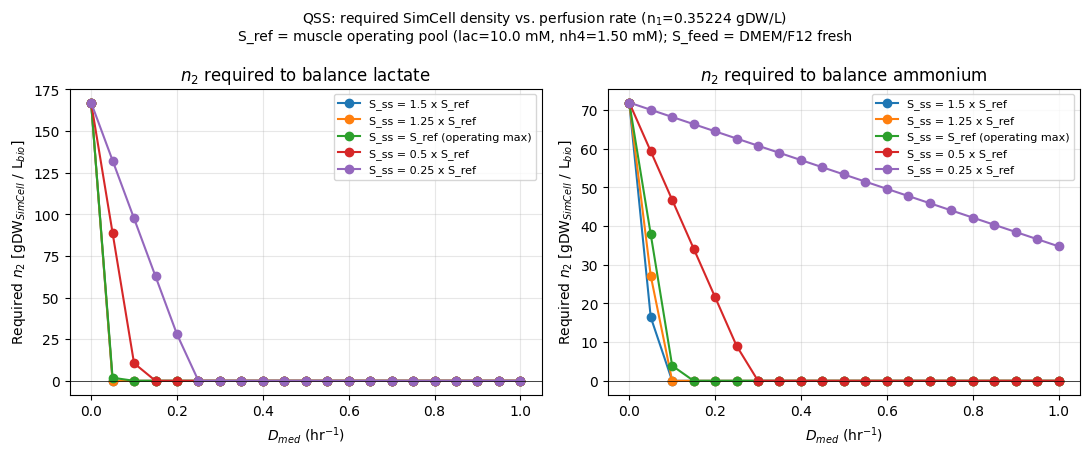


  FLUX DIAGNOSTIC — t=0 (pool lac=0.500, nh4=0.310, arg=0.500 mM)
  Pool: lac_e=0.5000  nh4_e=0.3100  arg_e=0.5000 mM
  n_atp_eff=10.0000  Ptot_now=40000.0 mg/L_cyto
  Ptot0 (reference) = 40000.0 mg/L_cyto  →  phi = 1.0000
  Flux                               mM_cyto/hr    mM_bio/hr
  ----------------------------------------------------------------------
  v_lacT  lactate import                1.41176      0.12706
  v_nh3   NH3 diffusion               -51.78329     -4.66050
  v_nh4T  NH4 ionic                     0.00002      0.00000
  v1      lldD+PDH                      0.00000      0.00000
  v2      ArgD (rate-limit)             0.03341      0.00301
  v_tca   TCA+ETC (×n_atp_eff)         71.73554      6.45620
  v_ppk   PPK                         123.86563     11.14791
  v_argT  ArgO export                   0.00041      0.00004
  v_r     protein synth/class           0.00950      0.00086
  v_maint maintenance                   3.00000      0.27000

  -- ATP balance (cyto units, n

ValueError: too many values to unpack (expected 2)

In [34]:
# ═════════════════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    from cobra.io import load_json_model
    import matplotlib.pyplot as plt

    candidate_gem_dirs = [
        PROJECT_DIR / "data" / "mammal",
        PROJECT_DIR / "data" / "gems",
        PROJECT_DIR.parent / "PigMNet2025" / "data" / "gems",
    ]
    GEMS_DIR = next((p for p in candidate_gem_dirs if p.exists()), None)
    if GEMS_DIR is None:
        searched = "\n".join(str(p) for p in candidate_gem_dirs)
        raise FileNotFoundError(
            "Could not find a data/gems directory. Looked in:\n"
            f"{searched}"
        )

    ipsc_core = load_json_model(GEMS_DIR / "iPSC_core.json")
    Adata     = pd.read_csv(GEMS_DIR / "EnzymeActivity.csv")
    A_dict    = {Adata["Rxn"][i]: Adata["Activity(mmol/hr/g)"][i]
                 for i in range(len(Adata.index))}

    pool_init = dict(MEDIUM_CONC_DMEM_F12)
    Ptot_ref  = 200_000.0

    y1_0 = make_y1_0(
        lac_e_0=pool_init["lac"], nh4_e_0=pool_init["nh4"],
        arg_e_0=pool_init["arg"],
        Ptot_ref=Ptot_ref,
        atp0=9.6, A_tot=10.16, polyp0=2.0,
        nh4_c0=0.1, arg_c0=0.01, accoa0=0.1, n_atp_eff0=10.0,
    )

    N_cells_0 = 1e9   # 1 L bioreactor, 10^6 cells/mL
    n1_gDW = gDW_from_cell_count(N_cells_0)
    D_med = 0.05      # 1.1 V_reactor/day

    # Single-point QSS report at the baseline
    qss = qss_density_report(
        ipsc_core,
        A_dict,
        n1_gDW=n1_gDW,
        D_med=D_med,
        Ptot_ref=Ptot_ref,
    )

    # Scan D_med across S_target cases
    df_scan = scan_qss_density_vs_Dmed(
        ipsc_core,
        A_dict,
        n1_gDW=n1_gDW,
        D_med_grid=np.linspace(0.0, 1.0, 21),
        plot_path=str(OUTPUT_DIR / "qss_n2_required_vs_Dmed.png"),
        csv_path=str(OUTPUT_DIR / "qss_n2_required_vs_Dmed.csv"),
        Ptot_ref=Ptot_ref,
    )

    results, monitor = run_coupled(
        gem_model=ipsc_core, A_dict=A_dict,
        pool_init=pool_init, N_cells_0=N_cells_0, y1_0=y1_0,
        T=60.0, dt=0.1,
        Ptot_ref=Ptot_ref,
        ptot=0.67366, O_frac=0.5953, NGAM=2.2771, Dr=0.01,
        r=0.01, Ke=0.5, m_ATP=3.0,
        k_eff=1.0, D_med=0.1,
        stab_warn=0.10, stab_halt=0.25, halt_on_stab=False, stab_abs_tol=0.10,
        conv_tol=0.01, conv_window=10, stop_on_conv=False,
        adaptive=False,
    )

    monitor.to_dataframe().to_csv(str(OUTPUT_DIR / "coupled_monitor.csv"), index=False)

    sug = suggest_pfracs_balance(results, P_FRACS, t_start=10.0)
    print("Mean Porcine cell lactate production (mM/hr):", sug["prod_lac"])
    print("Mean SimCell lactate uptake (mM/hr):", sug["upt_lac"])
    print("Suggested lacT fraction multiplier:", sug["scale_lacT"])

    print("Mean Porcine cell NH4 production (mM/hr):", sug["prod_nh4"])
    print("Mean SimCell NH4 uptake (mM/hr):", sug["upt_nh4"])
    print("Suggested P2 fraction multiplier:", sug["scale_P2"])

    print("New P_FRACS:", sug["P_FRACS_new"])

    t = results["t"]
    fig, axes = plt.subplots(3, 3, figsize=(17, 12))
    fig.suptitle("Coupled Porcine cell dFBA + SimCell kinetic ODE", fontsize=10)

    axes[0,0].plot(t, results["S_lac"], label="lac")
    axes[0,0].plot(t, results["S_nh4"], label="nh4")
    axes[0,0].plot(t, results["S_arg"], label="arg", ls="--")
    axes[0,0].set(xlabel="hr", ylabel="mM", title="Pool: cross-feeding")
    axes[0,0].legend()

    axes[0,1].plot(t, results["S_glc"], label="glc")
    axes[0,1].plot(t, results["S_gln"], label="gln")
    axes[0,1].set(xlabel="hr", ylabel="mM", title="Pool: Porcine cell substrates")
    axes[0,1].legend()

    axes[0,2].plot(t, results["n1_gDW"], label="Porcine cell (gDW/L)")
    axes[0,2].axhline(CELL_DENSITY_DCW, ls="--", color="orange",
                       label="SimCell (fixed)")
    axes[0,2].set(xlabel="hr", ylabel="gDW/L", title="Cell densities")
    axes[0,2].legend()

    axes[1,0].plot(t, results["y1_lac_c"], label="lac_c")
    axes[1,0].plot(t, results["y1_accoa"], label="accoa")
    axes[1,0].plot(t, results["y1_nh4_c"], label="nh4_c")
    axes[1,0].set(xlabel="hr", ylabel="mM_cyto", title="SimCell intracellular")
    axes[1,0].legend()

    A_tot_0 = results["y1_atp"][0] + results["y1_adp"][0]
    axes[1,1].plot(t, results["y1_atp"], label="ATP")
    axes[1,1].axhline(A_tot_0, ls=":", color="gray", alpha=0.6)
    axes[1,1].set(xlabel="hr", ylabel="mM", title=f"ATP (A_tot={A_tot_0:.2f})")
    axes[1,1].legend()

    axes[1,2].semilogy(t, np.maximum(results["y1_adp"], 1e-6), label="ADP")
    axes[1,2].set(xlabel="hr", ylabel="mM (log)", title="ADP")
    axes[1,2].legend(); axes[1,2].grid(True, which="both", alpha=0.3)

    axes[2,0].plot(t, results["y1_arg_c"], label="arg_c")
    axes[2,0].set(xlabel="hr", ylabel="mM_cyto", title="Arginine intracellular")
    axes[2,0].legend()

    axes[2,1].plot(t, results["Ptot"], label="Ptot (tracked)")
    axes[2,1].axhline(SUM_P_FRACS * Ptot_ref, ls=":", color="gray",
                       label=f"Ptot0={SUM_P_FRACS * Ptot_ref:.0f}")
    axes[2,1].set(xlabel="hr", ylabel="mg/L_cyto",
                   title="SimCell tracked protein")
    axes[2,1].legend()

    axes[2,2].plot(t, results["y1_n_atp_eff"], label="n_atp_eff")
    axes[2,2].set(xlabel="hr", ylabel="—",
                   title="ETC effective ATP yield")
    axes[2,2].legend()

    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / "coupled_results.png"), dpi=150)
    plt.show()

    # Lactate
    plt.figure(figsize=(10,4))
    plt.plot(t, results["rate_ipsc_lac"], label="Porcine cell lactate (mM/hr, +secretion)")
    plt.plot(t, -results["rate_sc_lac"], label="SimCell lactate uptake (mM/hr, +uptake)")
    plt.axhline(0, color="k", lw=0.8)
    plt.xlabel("hr"); plt.ylabel("mM_bio/hr"); plt.title("Lactate rates")
    plt.legend(); plt.tight_layout()

    # NH4
    plt.figure(figsize=(10,4))
    plt.plot(t, results["rate_ipsc_nh4"], label="Porcine cell NH4 (mM/hr, +secretion)")
    plt.plot(t, -results["rate_sc_nh4"], label="SimCell NH4 uptake (mM/hr, +uptake)")
    plt.axhline(0, color="k", lw=0.8)
    plt.xlabel("hr"); plt.ylabel("mM_bio/hr"); plt.title("NH4 rates")
    plt.legend(); plt.tight_layout()
    plt.show()
